# Heterogeneous slope in Doubrava-Kozinec and its stability (LL method)


## Notes Before Running
- Activate local environment: `source setup/activate_optimized_octave.sh`
- Activate Jupyter venv: `source .venv/bin/activate`
- In Jupyter, select kernel **Octave (local-rsb)**


In [1]:
close all; clearvars; clc;
%plot -f png -r 600
pkg load sparsersb;

try
    graphics_toolkit('qt');
catch
    graphics_toolkit('gnuplot');
end
set(0, 'defaultfigurevisible', 'off');

fprintf('Working directory: %s\n', pwd);
fprintf('Graphics toolkit: %s\n', graphics_toolkit());



Working directory: /home/beremi/repos/slope_stability/slope_stability
Graphics toolkit: qt


## Heterogeneous slope in Doubrava-Kozinec and its stability (LL method)


=========================================================================

 This program solves a 2D slope stability problem by the limit
 load (LL) method described in (Sysala et al., CAS 2025). The Mohr-
 Coulomb yield criterion, Davis approach, standard finite elements
 (P1, P2 or P4 elements) and meshes with different densities are
 considered. For P2 elements, the 7-point Gauss quadrature
 is used. To find the safety factor of the LL method, the indirect
 continuation technique is used. A heterogeneous slope from the locality
 Doubrava-Kozinec is considered, see (Sysala et al., NAG 2021)

======================================================================



## Main input data


In [2]:
% elem_type - type of finite elements; available choices: 'P1', 'P2', 'P4'
elem_type='P2';

% Davis_type - choice of Davis' approach; available choices: 'A','B','C'
Davis_type='B';

% Material parameters for each subdomain. In the following table, we
% specify in each column the following material parameters, respectively:
% [c0, phi, psi, young, poisson, gamma_sat, gamma_unsat], where
%    c0 ... Cohesion (c)
%    phi ... Friction angle (phi in degrees)
%    psi ... Dilatancy angle (psi in degrees)
%    young ... Young's modulus (E)
%    poisson ...  Poisson's ratio (nu)
%    gamma_sat ...   Specific weight - saturated (gamma_sat in kN/m^3)
%    gamma_unsat ... Specific weight - unsaturated (gamma_unsat in kN/m^3)
% If gamma_sat and gamma_unsat are not distinguished, use the same values
% for these parameters. Each row of the table represents one subdomain. If
% a homogeneous body is considered, only one row is prescribed.
mat_props = ...
    [9,  26, 0, 16000, 0.4, 20.3, 20.7;  % Subdomain #1
    2,  33, 0, 16000, 0.4, 19.0, 20.5;  % Subdomain #2
    5,  27, 0, 16000, 0.4, 19.4, 21.4;  % Subdomain #3
    3,  13, 0, 16000, 0.4, 20.0, 20.5;  % Subdomain #4
    5,  27, 0, 16000, 0.4, 19.4, 21.4;  % Subdomain #5 (same as #3)
    3,  13, 0, 16000, 0.4, 20.0, 20.5;  % Subdomain #6 (same as #4)
    1,  45, 0, 16000, 0.4, 20.5, 20.6]; % Subdomain #7


## Data from the reference element


In [3]:
% quadrature points and weights for volume integration
[Xi, WF] = ASSEMBLY.quadrature_volume_2D(elem_type);
% local basis functions and their derivatives
[HatP,DHatP1,DHatP2] = ASSEMBLY.local_basis_volume_2D(elem_type, Xi);


## Creation/loading of the finite element mesh


In [4]:
% Available Kozinec mesh family in meshes/Kozinec/ (nodes / elements):
%   P1:  3656 / 7026
%   P2: 14337 / 7026
[coord, elem, Q, material_identifier] = MESH.load_mesh_Kozinec(elem_type, 'meshes/Kozinec/');

% Uncomment to reduce matrix bandwidth via Reverse Cuthill-McKee node reordering:
% [coord, elem, ~, Q] = MESH.reorder_mesh(coord, elem, [], Q);

% number of nodes, elements and integration points + print
n_n=size(coord,2);
n_unknown=length(coord(Q)); % number of unknowns
n_e=size(elem,2);           % number of elements
n_q=length(WF);             % number of quadratic points
n_int = n_e*n_q ;           % total number of integrations points
%
fprintf('\n');
fprintf('Mesh data:');
fprintf('  number of nodes =%d ',n_n);
fprintf('  number of unknowns =%d ',n_unknown);
fprintf('  number of elements =%d ',n_e);
fprintf('  number of integration points =%d ',n_int);
fprintf('\n');



Mesh data:  number of nodes =14337   number of unknowns =28536   number of elements =7026   number of integration points =49182 


## Material Parameters at Integration Points


In [5]:
% Fields with prescribed material properties
fields = {'c0',      ... % Cohesion (c)
    'phi',     ... % Friction angle (phi in degrees)
    'psi',     ... % Dilatancy angle (psi in degrees)
    'young',   ... % Young's modulus (E)
    'poisson', ... % Poisson's ratio (nu)
    'gamma_sat', ... % Specific weight - saturated (gamma_sat in kN/m^3)
    'gamma_unsat'};  % Specific weight - unsaturated (gamma_unsat in kN/m^3)

% Convert properties to structured format.
materials = cellfun(@(x) cell2struct(num2cell(x), fields, 2), num2cell(mat_props, 2), 'UniformOutput', false);

% saturation - a prescribed logical array indicating integration points
%              where the body is saturated. If gamma_sat and gamma_unsat
%              are the same, set saturation=true(1,n_int). Otherwise,
%              this logical array is derived from a given phreatic surface.
saturation = ASSEMBLY.saturated_zone(coord,elem,HatP);

% Material parameters at integration points.
[c0, phi, psi, shear, bulk, lame, gamma] = ...
    ASSEMBLY.heterogenous_materials(material_identifier, saturation, n_q, materials);


## Assembling


In [6]:
% Assembling of the elastic stiffness matrix
[K_elast,B,WEIGHT,DPhi1_out,DPhi2_out]=ASSEMBLY.elastic_stiffness_matrix_2D(elem,coord,...
    DHatP1,DHatP2,WF,shear,lame);

% volume forces at integration points, size(f_V_int)=(2,n_int)
f_V_int = [zeros(1,n_int);-gamma] ;
% vector of volume forces
f_V=ASSEMBLY.vector_volume_2D(elem,coord,f_V_int,HatP,WEIGHT);


## Input parameters for continuation (for the limit load analysis)


In [7]:
d_t_min = 1e-4;                % Minimal increment of load factor t.
step_max = 100;                % Maximum number of continuation steps.
LL_omega_max = 200000;            % Maximum value of the control parameter omega.


## Input parameters for Newton's solvers


In [8]:
it_newt_max = 50;               % Number of Newton's iterations
it_damp_max = 10;               % Number of iterations within line search
tol = 1e-4;                     % Relative tolerance for Newton's solvers
r_min = 1e-4;                   % Basic minimal regularization of the stiffness matrix


## Defining linear solver


In [9]:
% agmg folder is baked into LINEAR_SOLVERS.set_linear_solver
solver_type = 'DFGMRES_HYPRE_BOOMERAMG'; % Type of solver: "DIRECT", "DFGMRES_ICHOL", "DFGMRES_AGMG", "DFGMRES_HYPRE_BOOMERAMG"

linear_solver_tolerance = 1e-1;
linear_solver_maxit = 100;
deflation_basis_tolerance = 1e-3;
linear_solver_printing = 0;

% Optional BoomerAMG options (used when solver_type contains BOOMERAMG).
boomeramg_opts = struct('threads', 16, 'print_level', 0, ...
    'use_as_preconditioner', true);

[linear_system_solver] = LINEAR_SOLVERS.set_linear_solver(solver_type, ...
    linear_solver_tolerance, linear_solver_maxit, deflation_basis_tolerance, linear_solver_printing, Q, coord, boomeramg_opts);


## Constitutive problem and matrix builder


In [10]:
dim = 2;
n_strain = dim * (dim + 1) / 2;
constitutive_matrix_builder = CONSTITUTIVE_PROBLEM.CONSTITUTIVE(B, c0, phi, psi, Davis_type, shear, bulk, lame, WEIGHT, n_strain, n_int, dim);
% Enable element-level tangent assembly path for 2D B*D*B values.
constitutive_matrix_builder.set_element_data(elem, DPhi1_out, DPhi2_out);
disp(['2D element-level tangent mex enabled = ' , num2str(constitutive_matrix_builder.elem_use_mex)]);
disp(['2D constitutive mex enabled = ' , num2str(constitutive_matrix_builder.use_2D_mex)]);


%--------------------------------------------------------------------------


Element data set: n_p=6, n_e=7026, n_q=7, mex=1
2D element-level tangent mex enabled = 1
2D constitutive mex enabled = 1


## Profiler Setup


In [11]:
profiler = PROFILING.Profiler();
constitutive_matrix_builder.profiler = profiler;
linear_system_solver.profiler = profiler;


## Computation of the limit load factor by the indirect continuation


In [12]:
fprintf('\n Indirect continuation method for the LL method\n');
tic;

% Compute the elastic displacement field as a starting point.
constitutive_matrix_builder.reduction(1.0);
U_elast = zeros(2, n_n);              % Elastic displacement vector.
linear_system_solver.setup_preconditioner(K_elast(Q, Q));
U_elast(Q) = linear_system_solver.solve(K_elast(Q, Q), f_V(Q));
linear_system_solver.expand_deflation_basis(U_elast(Q));
omega_el = f_V(Q)' * U_elast(Q);        % Work of external forces.

% Set the initial increment of omega.
d_omega_ini = omega_el / 10;
% Scale the elastic displacement field.
U_elast = U_elast / 10;

% Run the indirect continuation method for limit load analysis.
[U, t_hist, omega_hist, U_max_hist] = CONTINUATION.LL_indirect_continuation(...
    d_omega_ini, d_t_min, step_max, LL_omega_max, ...
    it_newt_max, it_damp_max, tol, r_min, K_elast, U_elast, Q, f_V, ...
    constitutive_matrix_builder, linear_system_solver.copy());

time_run = toc;
fprintf("Running_time = %f \n", time_run);


if ~isempty(strfind(upper(char(solver_type)), 'BOOMERAMG'))
    LINEAR_SOLVERS.hypre_boomeramg_clear();
end



 Indirect continuation method for the LL method
Step 2: omega_target=14413.8, d_omega=14413.8
Initialising K_r(Q,Q) sparse pattern ... done  (0.5 s, n_Q = 28536, nnz = 646716)
Building element scatter map ... done  (0.1 s, n_local_dof=12, map_size=8 MB)
newton_ind_LL summary: status=converged, it=4, rel_resid=3.730145e-05, lin_it_total=[W:0,V:6], wall_time=0.89 s
  accepted: t=0.0995211, d_t=0.0995211, omega=14413.8, d_omega=14413.8, U_max=0.171694
Step 3: omega_target=28827.7, d_omega=14413.8
newton_ind_LL summary: status=converged, it=6, rel_resid=2.378503e-05, lin_it_total=[W:0,V:14], wall_time=0.54 s
  accepted: t=0.198999, d_t=0.0994778, omega=28827.7, d_omega=14413.8, U_max=0.343125
Step 4: omega_target=43241.5, d_omega=14413.8
newton_ind_LL summary: status=converged, it=5, rel_resid=5.230398e-05, lin_it_total=[W:0,V:12], wall_time=0.46 s
  accepted: t=0.298446, d_t=0.0994469, omega=43241.5, d_omega=14413.8, U_max=0.514225
Step 5: omega_target=57655.4, d_omega=14413.8
newton_ind

## Postprocessing - visualization of selected results


In [13]:
if false
VIZ.plot_deviatoric_strain_2D(U,coord,elem,B);
VIZ.plot_displacements_2D(U,coord,elem);
% Visualization of the continuation curve: omega -> lambda.
figure; hold on; box on; grid on;
plot(omega_hist, t_hist, '-o');
title('Indirect continuation method for the LL method', 'Interpreter', 'latex');
xlabel('Control variable - $\omega$', 'Interpreter', 'latex');
ylabel('Load factor - $t$', 'Interpreter', 'latex');

end


## Profiler Summary


In [14]:
if exist('profiler', 'var')
    profiler.print_summary();
end



  Profiler Summary
  Time      %       Calls  Operation
  --------- ------ ------  ------------------------------
     34.13s  44.4%   1535  DFGMRES.solve
     17.00s  22.1%    735  DFGMRES.update_preconditioner
     12.14s  15.8%    767  DFGMRES.A_orthogonalize
      3.73s   4.8%   1701  CONSTITUTIVE.build_F
      3.26s   4.2%    790  CONSTITUTIVE.stress_tangent
      2.73s   3.5%    911  CONSTITUTIVE.stress
      2.43s   3.2%    767  CONSTITUTIVE.build_K_tangent_QQ_vals
      0.79s   1.0%     33  DFGMRES.setup_preconditioner
      0.73s   0.9%   1558  DFGMRES.expand_deflation_basis
      0.01s   0.0%      1  CONSTITUTIVE.reduction
  --------- ------ ------  ------------------------------
     76.94s                TOTAL

  Sub-profile: DFGMRES.solve  (34.13s total, 1535 calls)
  --------- ------ ------  ------------------------------
     16.90s  49.5%    745  precond_apply
      6.40s  18.8%   1535  init
      5.28s  15.5%    745  deflation_project
      1.45s   4.2%    745  arnold

## Unified Postprocessing via SolutionPlotter


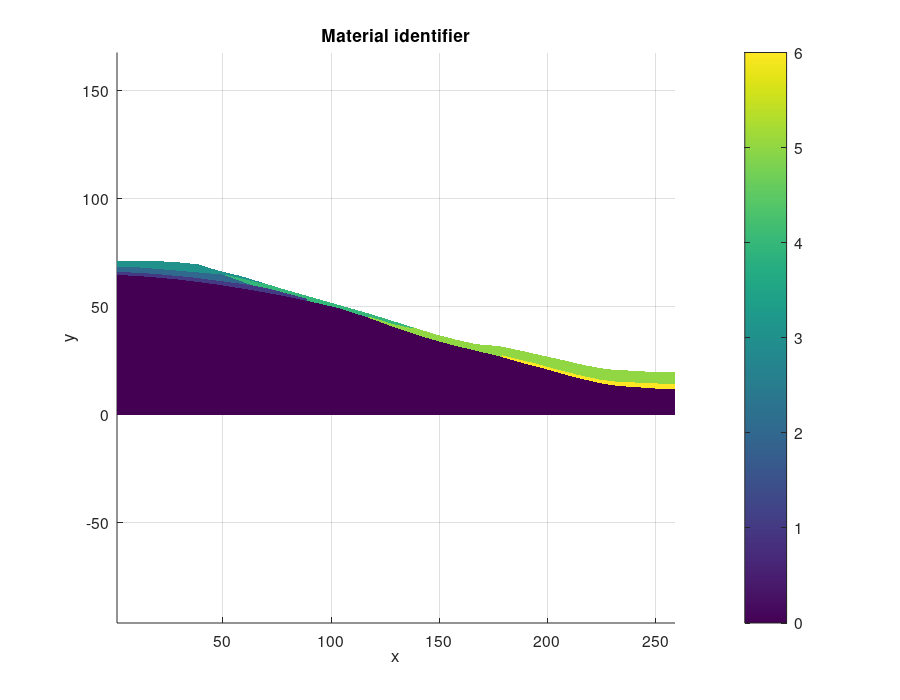

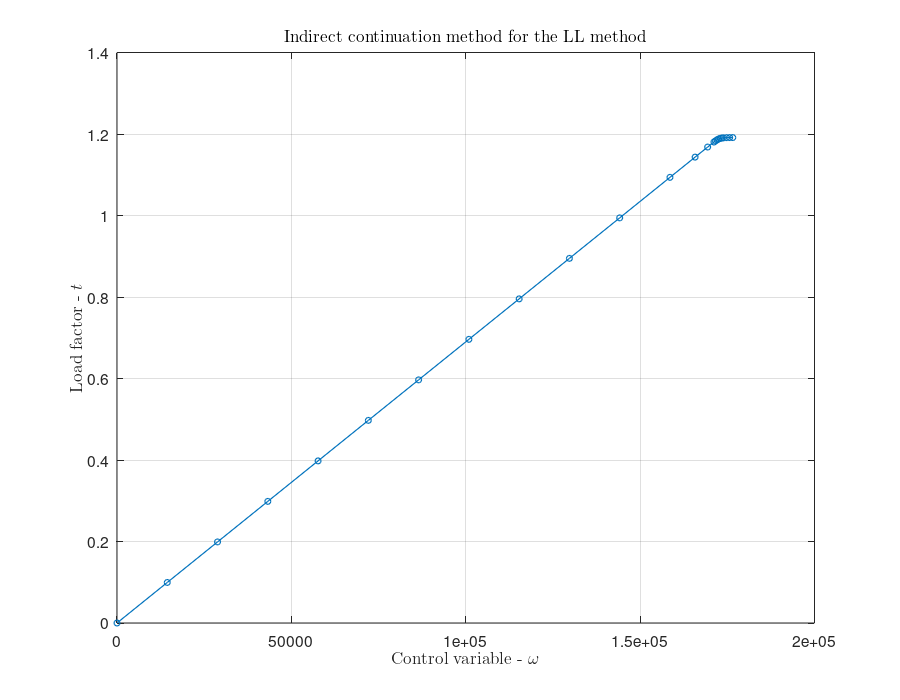

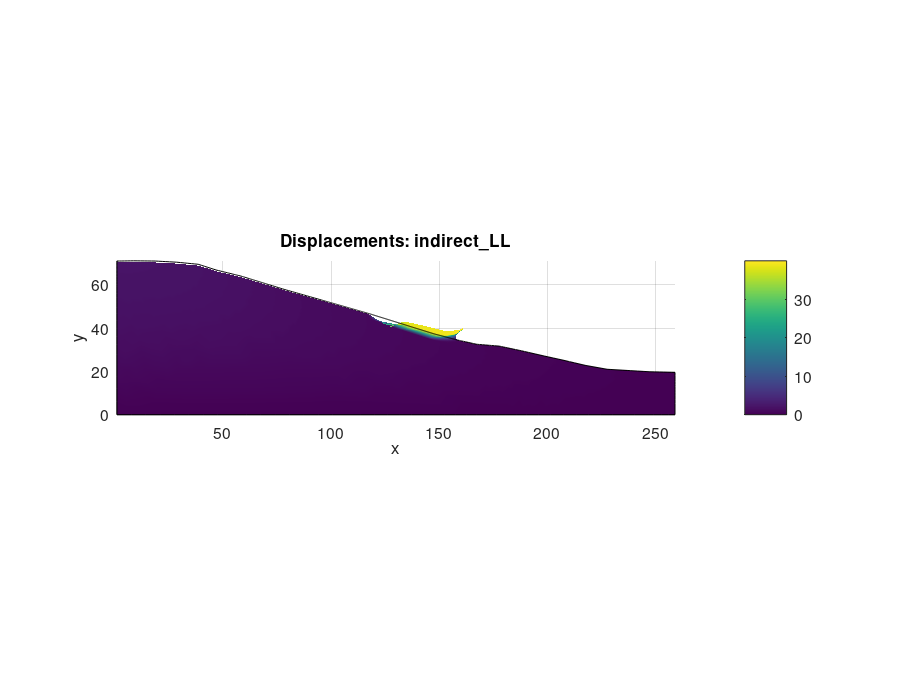

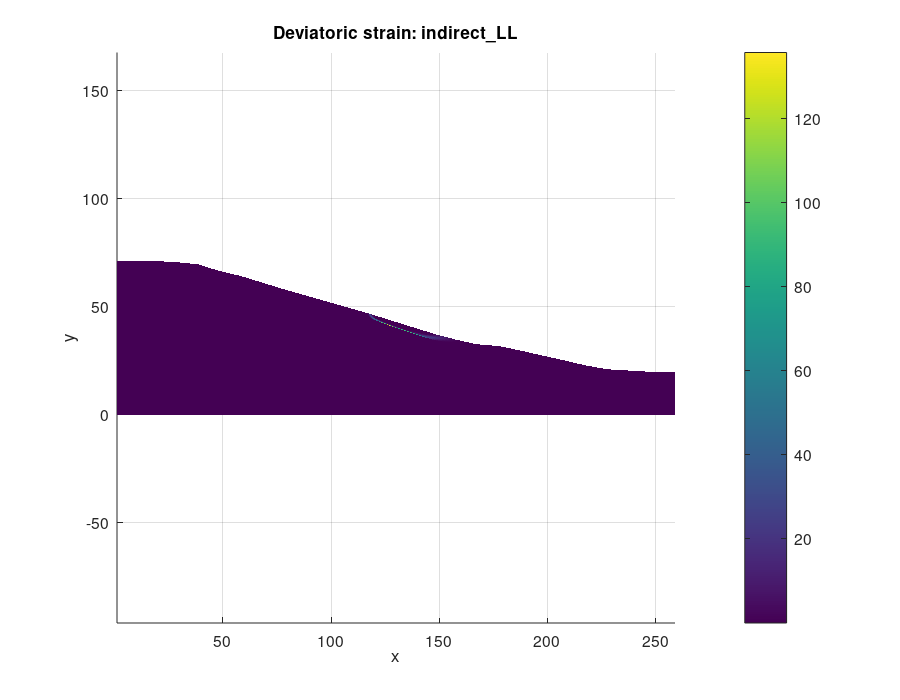

In [15]:
plotter = VIZ.SolutionPlotter(coord, elem, [], B, [], 'comsol');

if exist('material_identifier', 'var')
    plotter.set_material_identifier(material_identifier);
end
if exist('mater_sat', 'var')
    plotter.set_element_saturation(mater_sat);
end
if exist('pw', 'var')
    plotter.set_pore_pressure(pw);
end

if exist('U2', 'var') && exist('lambda_hist2', 'var') && exist('omega_hist2', 'var')
    if exist('Umax_hist2', 'var')
        Umax2 = Umax_hist2;
    else
        Umax2 = [];
    end
    plotter.add_solution('direct', U2, lambda_hist2, omega_hist2, Umax2, struct( ...
        'title', 'Direct continuation method', ...
        'xlabel', 'Control variable - $\omega$', ...
        'ylabel', 'strength reduction factor - $\lambda$', ...
        'marker', '-o'));
end

if exist('U3', 'var') && exist('lambda_hist3', 'var') && exist('omega_hist3', 'var')
    if exist('Umax_hist3', 'var')
        Umax3 = Umax_hist3;
    else
        Umax3 = [];
    end
    plotter.add_solution('indirect', U3, lambda_hist3, omega_hist3, Umax3, struct( ...
        'title', 'Indirect continuation method', ...
        'xlabel', 'Control variable - $\omega$', ...
        'ylabel', 'strength reduction factor - $\lambda$', ...
        'marker', '-o'));
end

if exist('U', 'var') && exist('t_hist', 'var') && exist('omega_hist', 'var')
    if exist('U_max_hist', 'var')
        UmaxLL = U_max_hist;
    else
        UmaxLL = [];
    end
    plotter.add_solution('indirect_LL', U, t_hist, omega_hist, UmaxLL, struct( ...
        'title', 'Indirect continuation method for the LL method', ...
        'xlabel', 'Control variable - $\omega$', ...
        'ylabel', 'Load factor - $t$', ...
        'marker', '-o'));
end

if plotter.n_solutions > 0
    plotter.plot_deviatoric_strain();
    plotter.plot_displacements();
    plotter.plot_convergence();
end

if exist('pw', 'var')
    plotter.plot_pore_pressure();
end
if exist('material_identifier', 'var')
    plotter.plot_material_map();
end
if exist('mater_sat', 'var')
    plotter.plot_saturation();
end
